In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns
from sklearn.metrics import silhouette_score

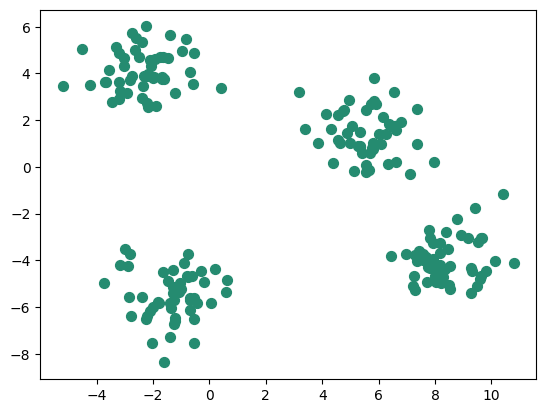

In [12]:
X, y_true = make_blobs (n_samples=200, centers= 4, cluster_std=1.0 )
plt.scatter(X[:, 0], X[:, 1], s=50, color= "#258b70")

In [13]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

y_kmeans = kmeans.predict(X)
y_kmeans


array([1, 1, 2, 1, 2, 0, 2, 0, 2, 0, 1, 1, 0, 1, 2, 0, 2, 0, 2, 0, 2, 1,
       0, 1, 2, 2, 2, 1, 1, 1, 2, 0, 1, 0, 1, 2, 0, 1, 1, 2, 0, 2, 1, 2,
       1, 1, 1, 2, 1, 0, 1, 1, 1, 0, 2, 1, 0, 1, 1, 1, 1, 0, 1, 1, 2, 1,
       1, 1, 2, 1, 1, 0, 2, 1, 2, 2, 1, 1, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2,
       2, 1, 2, 0, 2, 1, 1, 2, 1, 1, 1, 1, 0, 2, 0, 2, 1, 1, 0, 1, 1, 0,
       2, 0, 1, 0, 0, 1, 0, 1, 2, 0, 2, 0, 0, 1, 2, 0, 1, 1, 0, 1, 2, 1,
       0, 2, 1, 2, 0, 0, 0, 2, 1, 1, 1, 2, 1, 0, 1, 2, 2, 2, 0, 1, 1, 0,
       1, 2, 2, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 2, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 2, 1, 0, 1, 1, 1, 0, 1, 0, 2, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

<Figure size 500x500 with 0 Axes>

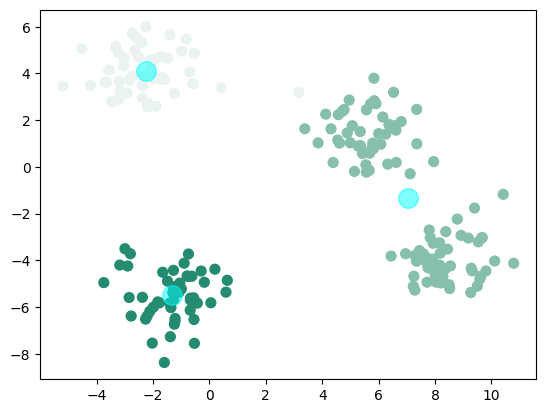

<Figure size 500x500 with 0 Axes>

In [15]:
plt.scatter(X[:, 0], X[:, 1], s=50, c=y_kmeans, cmap=sns.light_palette("#258b70", as_cmap=True))

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c = "cyan", s= 200, alpha=0.5)
plt.figure(figsize=(5, 5))

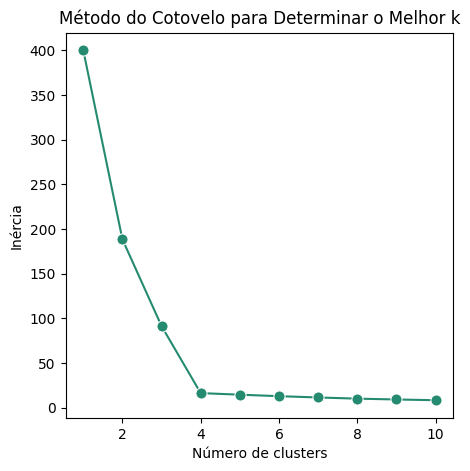

In [60]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot do método do cotovelo usando Seaborn
plt.figure(figsize=(5, 5))
sns.lineplot(x=K, y=inertia, marker='o', markersize=8, color='#258b70')
plt.xlabel('Número de clusters')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo para Determinar o Melhor k')
plt.show()

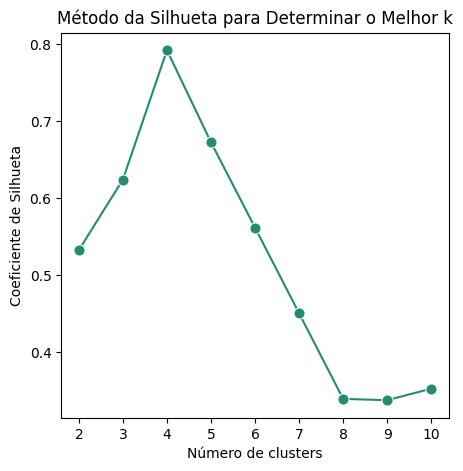

In [63]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

silhouette_scores = []
K = range(2, 11)  # A métrica de silhueta não é definida para k=1

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plot do método da silhueta usando Seaborn
plt.figure(figsize=(5, 5))
sns.lineplot(x=K, y=silhouette_scores, marker='o', markersize=8, color='#258b70')
plt.xlabel('Número de clusters')
plt.ylabel('Coeficiente de Silhueta')
plt.title('Método da Silhueta para Determinar o Melhor k')
plt.show()